# India Drug Approval Gap Analysis
## CDSCO Approvals (2025) vs WHO GBD 2019


In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
print("Libraries loaded")

Libraries loaded


In [2]:
df = pd.read_csv("../data/cdsco_approvals_2025.csv")
print(f"Loaded {len(df)} drugs")
print(df["therapeutic_area"].value_counts())

Loaded 51 drugs
therapeutic_area
Cardiovascular         10
Immunology              6
Oncology                5
Diabetes / Obesity      4
Infectious disease      4
Diagnostic              3
Musculoskeletal         3
Respiratory (COPD)      2
Blood product           2
Neurology               2
Gastrointestinal        2
Reproductive health     2
Hematology              2
Dermatology             2
Inflammation            1
Ophthalmology           1
Name: count, dtype: int64


In [3]:
with open("../sql/gap_analysis.sql","r") as f:
    sql = f.read()
results = duckdb.sql(sql).fetchdf()
print(results)

       therapeutic_area  burden_rank  approval_count  approval_rank  gap
0       Musculoskeletal           15               3              6    9
1            Immunology           10               6              2    8
2            Diagnostic           14               3              6    8
3         Blood product           13               2              8    5
4            Hematology           12               2              8    4
5    Infectious disease            6               4              4    2
6        Cardiovascular            2              10              1    1
7           Dermatology            9               2              8    1
8          Inflammation           16               1             15    1
9              Oncology            3               5              3    0
10  Reproductive health            8               2              8    0
11     Gastrointestinal            7               2              8   -1
12   Diabetes / Obesity            1               

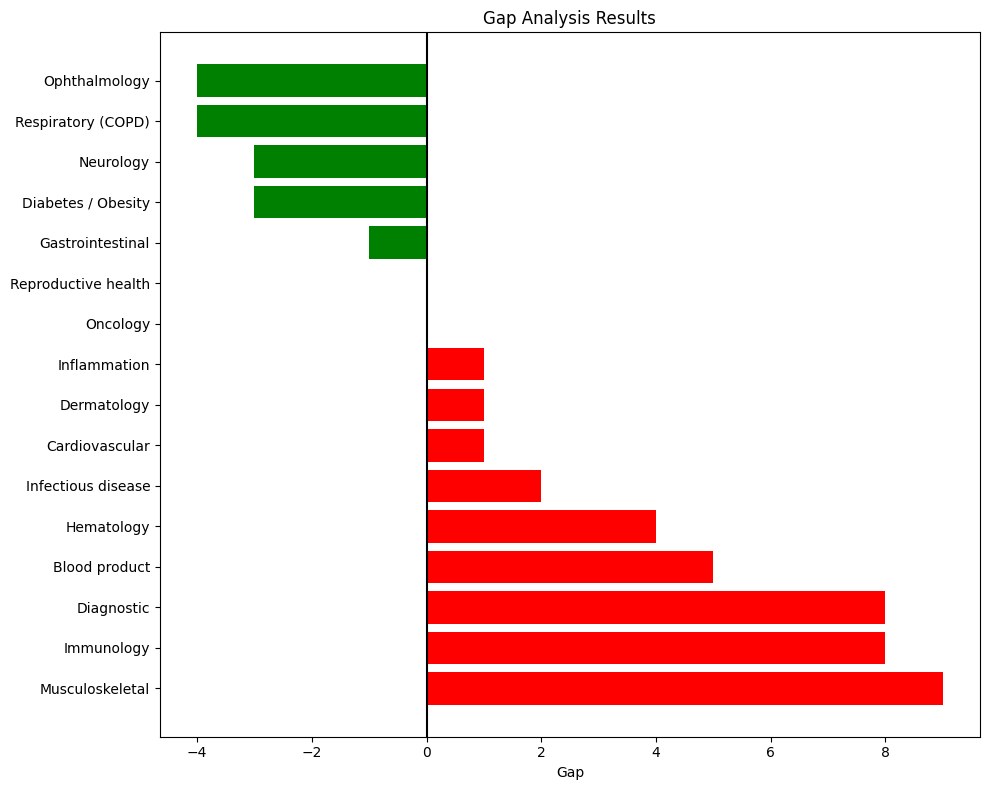

In [4]:
fig, ax = plt.subplots(figsize=(10,8))
colors = ["red" if x>0 else "green" for x in results["gap"]]
ax.barh(results["therapeutic_area"], results["gap"], color=colors)
ax.axvline(x=0, color="black")
ax.set_xlabel("Gap")
ax.set_title("Gap Analysis Results")
plt.tight_layout()
plt.savefig("../visualizations/gap_chart.png")
plt.show()